# Stage 2 — Standard (Additive) LoRA Fine-Tuning
## Model: `google/gemma-2-9b-it` | Dataset: CB1 (6-Class Cyberbullying)

---

## Theory — Standard LoRA

**Standard LoRA — Wf = W + AB**

Standard LoRA adapts a pre-trained weight matrix W by adding a low-rank update:

> **Wf = W + AB**

where W ∈ ℝᵐˣⁿ is the frozen pre-trained weight, A ∈ ℝᵐˣʳ and B ∈ ℝʳˣⁿ are the trainable adapter matrices, and r ≪ min(m, n) is the rank — a small number that controls how many parameters are trained. Only A and B are updated during fine-tuning; W remains completely frozen. The low-rank constraint makes this parameter-efficient: instead of updating all m×n weights, only 2×r×n parameters are trained. At initialisation, B is set to zero so the adapter contributes nothing and training starts from the pre-trained behaviour. This is the additive-only baseline in the generalised framework — it corresponds to setting L₁ = I (no multiplicative component).

---

### Bugs Fixed in This Version
| # | Bug | Fix Applied |
|---|-----|-------------|
| 1 | `calculate_effective_rank()` computed rank of ΔW (trivially = r) instead of full Wf | Corrected to compute rank of **Wf = W + ΔW** |
| 2 | Label mapping used wrong class names (`gender/sexual`, `ethnicity/race`) | Updated to match dataset: `gender`, `ethnicity` + all 6 classes |
| 3 | `lora_alpha=8` with `lora_rank=16` → scaling=0.5 (non-standard) | Set `lora_alpha = lora_rank` throughout |
| 4 | `EarlyStoppingCallback` imported but never added to trainer | Removed — meaningless with 1 epoch |

### Research-Level Issues Fixed
| # | Issue | Fix Applied |
|---|-------|-------------|
| R1 | Efficiency story requires rank dynamics | Added rank dynamics + efficiency curve (rank sweep r∈{4,8,16,32}) |
| R2 | Downsampling applied to already-balanced data | **Removed** — CB1 (6-class) has 1.37× imbalance ratio |
| R3 | MCC missing from evaluation | Added `matthews_corrcoef` to all metric reports |
| R4 | 75/10/15 split deviated from 75/25 protocol | **Fixed** — 75% train / 25% test; val carved from within train |
| R5 | Panels 3 & 4 (grad norm / per-epoch loss) meaningless at 1 epoch | **Removed** — stability plot restructured to 2-panel |

---

### Gemma-2-9B Specific Notes
- **HF Token required** — `google/gemma-2-9b-it` is a gated model; token loaded from Colab Secrets.
- **Batch size = 4** — 9B model is ~1.3× larger than Mistral-7B; halved to prevent OOM.
- **Learning rate = 5e-5** — conservative for 9B scale.
- **Stage 1 context** — Gemma-2-9B showed ICL interference in Stage 1 (ZS 0.502 > FS 0.497). LoRA fine-tuning bypasses this entirely — the model is being directly supervised, not prompted.

**GPU Required**: A100 (40GB) recommended for Gemma-2-9B-IT with 4-bit quantisation.

---
## Step 1: Install Required Libraries

In [1]:
!pip install -q -U \
    "transformers>=4.43.0" \
    "accelerate>=0.33.0" \
    "bitsandbytes>=0.43.0" \
    "peft>=0.11.1" \
    datasets \
    scikit-learn \
    matplotlib \
    seaborn

print("✓ All libraries installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 147.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 158.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 135.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 56.9 MB/s eta 0:00:00
✓ All libraries installed successfully.


---
## Step 2: Import Libraries and Initial Setup

**HF Token required**: `google/gemma-2-9b-it` is gated. Add `HF_TOKEN` to Colab Secrets
(key icon in the left sidebar) before running this cell.

In [2]:
import os
import random
import collections
import re
from typing import Dict, List

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (
    accuracy_score, f1_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef,
)
from transformers import (
    AutoModelForSequenceClassification, AutoTokenizer,
    BitsAndBytesConfig, TrainingArguments, Trainer, TrainerCallback,
)
from peft import LoraConfig, prepare_model_for_kbit_training, get_peft_model
from peft.tuners.lora import LoraLayer
from google.colab import drive, userdata

# ── Reproducibility ──────────────────────────────────────────────────────────
def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"✓ All random seeds fixed to {seed}.")

set_all_seeds(42)

# ── HuggingFace token (required for gated Gemma-2) ───────────────────────────
def load_hf_token() -> str:
    token = userdata.get('HF_TOKEN')
    if token is None:
        raise ValueError("HF_TOKEN not found. Add it via Colab Secrets (key icon in sidebar).")
    os.environ['HF_TOKEN'] = token
    print("✓ HuggingFace token loaded.")
    return token

HF_TOKEN = load_hf_token()

# ── Mount Google Drive ────────────────────────────────────────────────────────
drive.mount('/content/drive')
print("✓ Google Drive mounted.")

# ── GPU check ─────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

✓ All random seeds fixed to 42.
✓ HuggingFace token loaded.
Mounted at /content/drive
✓ Google Drive mounted.
✓ Device: cuda
  GPU: NVIDIA A100-SXM4-40GB
  VRAM: 42.4 GB


---
## Step 3: Global Configuration

**Gemma-2-9B specific decisions**:
- `TRAIN_BATCH_SIZE = 4` — 9B is ~1.3× larger than Mistral-7B; batch halved to prevent OOM.
- `EVAL_BATCH_SIZE = 8` — reduced accordingly.
- `LEARNING_RATE = 5e-5` — conservative for 9B scale; Mistral at 1e-4 showed high loss CV.
- `token=HF_TOKEN` passed to `from_pretrained` — gated model requires authentication.

In [3]:
# ════════════════════════════════════════════════════════════════════════════
# GLOBAL CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════

MODEL_NAME   = "google/gemma-2-9b-it"
NUM_LABELS   = 6
MAX_LENGTH   = 256

LORA_RANK    = 16
LORA_ALPHA   = 16
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q_proj', 'k_proj', 'v_proj', 'o_proj']
RANK_SWEEP   = [4, 8, 16, 32]

NUM_EPOCHS          = 1
LEARNING_RATE       = 5e-5   # conservative for 9B — 1e-4 caused high CV in Mistral-7B
TRAIN_BATCH_SIZE    = 4      # halved vs Mistral — 9B is ~1.3× larger
EVAL_BATCH_SIZE     = 8
WEIGHT_DECAY        = 0.01
EVAL_STEPS          = 200
LOGGING_STEPS       = 50
OUTPUT_DIR          = "/content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B"

CB1_PATH             = "/content/drive/MyDrive/Datasets/cb1.csv"
TRAIN_RATIO          = 0.75
TEST_RATIO           = 0.25
VAL_FROM_TRAIN       = 0.10
SIMILARITY_THRESHOLD = 0.90
RANDOM_STATE         = 42

LABEL_MAPPING = {
    'not_cyberbullying':   0,
    'gender':              1,
    'religion':            2,
    'ethnicity':           3,
    'age':                 4,
    'other_cyberbullying': 5,
}
ID2LABEL     = {v: k for k, v in LABEL_MAPPING.items()}
TARGET_NAMES = list(LABEL_MAPPING.keys())

print("✓ Configuration loaded.")
print(f"  Model      : {MODEL_NAME}")
print(f"  LoRA rank  : {LORA_RANK}  |  alpha: {LORA_ALPHA}  |  scaling: {LORA_ALPHA/LORA_RANK:.1f}")
print(f"  Epochs     : {NUM_EPOCHS}")
print(f"  Batch size : {TRAIN_BATCH_SIZE} train / {EVAL_BATCH_SIZE} eval  (reduced for 9B)")
print(f"  LR         : {LEARNING_RATE}  (conservative for 9B scale)")
print(f"  Split      : {int(TRAIN_RATIO*100)}% train+val / {int(TEST_RATIO*100)}% test  (protocol: 75/25)")
print(f"  Labels ({NUM_LABELS}) : {TARGET_NAMES}")

✓ Configuration loaded.
  Model      : google/gemma-2-9b-it
  LoRA rank  : 16  |  alpha: 16  |  scaling: 1.0
  Epochs     : 1
  Batch size : 4 train / 8 eval  (reduced for 9B)
  LR         : 5e-05  (conservative for 9B scale)
  Split      : 75% train+val / 25% test  (protocol: 75/25)
  Labels (6) : ['not_cyberbullying', 'gender', 'religion', 'ethnicity', 'age', 'other_cyberbullying']


---
## Step 4: Text Preprocessing

In [4]:
def preprocess_text_for_llm(text: str,
                             remove_hashtags: bool = False,
                             remove_emojis: bool = False) -> str:
    if not isinstance(text, str):
        return ""
    text = re.sub(r'\bRT\s+@\w+:\s*', '', text, flags=re.IGNORECASE)
    text = re.sub(r'http\S+|www\.\S+', '[URL]', text)
    text = re.sub(r'@\w+', '[USER]', text)
    if remove_hashtags:
        text = re.sub(r'#(\w+)', r'\1', text)
    if remove_emojis:
        text = text.encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'([!?.])\1+', r'\1', text)
    if len(text.split()) < 3:
        return ""
    return text

test_tweet = "RT @user123: Check this out http://example.com !!! @someone is so dumb"
print("Before:", test_tweet)
print("After: ", preprocess_text_for_llm(test_tweet))
print("\n✓ Preprocessing function defined.")

Before: RT @user123: Check this out http://example.com !!! @someone is so dumb
After:  Check this out [URL] ! [USER] is so dumb

✓ Preprocessing function defined.


---
## Step 5: Load and Clean the CB1 Dataset

In [5]:
print("═" * 60)
print("CB1 DATASET LOADING & CLEANING")
print("═" * 60)

df = pd.read_csv(CB1_PATH)
print(f"\n[1] Raw dataset loaded: {len(df):,} samples")

df = df.rename(columns={'tweet_text': 'text', 'cyberbullying_type': 'label'})

corrupt_mask = df['text'].astype(str).str.strip().isin(
    ['#NAME?', '#REF!', '#VALUE!', '#N/A', 'nan', ''])
n_corrupt = corrupt_mask.sum()
df = df[~corrupt_mask].reset_index(drop=True)
print(f"[2] Removed {n_corrupt} corrupt rows → {len(df):,} remaining")

df['text'] = df['text'].apply(preprocess_text_for_llm)
df = df[df['text'].str.strip().str.len() > 0].reset_index(drop=True)
print(f"[3] After preprocessing: {len(df):,} remaining")

text_label_counts = df.groupby('text')['label'].nunique()
conflicting_texts = text_label_counts[text_label_counts > 1].index
n_conflicting     = df['text'].isin(conflicting_texts).sum()
df = df[~df['text'].isin(conflicting_texts)].reset_index(drop=True)
print(f"[4] Removed {n_conflicting:,} annotation-conflict rows → {len(df):,} remaining")

before = len(df)
df = df.drop_duplicates(subset=['text'], keep='first').reset_index(drop=True)
print(f"[5] Removed {before - len(df):,} exact duplicates → {len(df):,} remaining")

before = len(df)
df = df[df['text'].str.split().str.len() >= 3].reset_index(drop=True)
print(f"[6] Removed {before - len(df):,} short texts → {len(df):,} remaining")

unknown_labels = set(df['label'].unique()) - set(LABEL_MAPPING.keys())
assert len(unknown_labels) == 0, f"Unknown labels: {unknown_labels}"

print("\n" + "═" * 60)
print("FINAL CB1 CLASS DISTRIBUTION")
print("═" * 60)
counts = df['label'].value_counts()
for label, count in counts.items():
    print(f"  {label:<25} {count:>6}  ({count/len(df)*100:.1f}%)")
print(f"  {'TOTAL':<25} {len(df):>6}")
imbalance = counts.max() / counts.min()
print(f"\n  Imbalance ratio : {imbalance:.2f}×  → no downsampling needed")
print("  Primary metric  : Macro F1  |  Secondary: MCC")

════════════════════════════════════════════════════════════
CB1 DATASET LOADING & CLEANING
════════════════════════════════════════════════════════════

[1] Raw dataset loaded: 47,692 samples
[2] Removed 0 corrupt rows → 47,692 remaining
[3] After preprocessing: 46,942 remaining
[4] Removed 3,250 annotation-conflict rows → 43,692 remaining
[5] Removed 358 exact duplicates → 43,334 remaining
[6] Removed 0 short texts → 43,334 remaining

════════════════════════════════════════════════════════════
FINAL CB1 CLASS DISTRIBUTION
════════════════════════════════════════════════════════════
  religion                    7979  (18.4%)
  age                         7972  (18.4%)
  ethnicity                   7920  (18.3%)
  gender                      7509  (17.3%)
  not_cyberbullying           6130  (14.1%)
  other_cyberbullying         5824  (13.4%)
  TOTAL                      43334

  Imbalance ratio : 1.37×  → no downsampling needed
  Primary metric  : Macro F1  |  Secondary: MCC


---
## Step 6: Stratified 75/25 Split with Near-Duplicate Check

In [6]:
print("═" * 60)
print("DATASET SPLITTING — Protocol: 75% train / 25% test")
print("═" * 60)

train_val_df, test_df = train_test_split(
    df, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=df['label'])
print(f"\n[1] Primary split → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")

print(f"\n[2] Near-duplicate check (threshold: {SIMILARITY_THRESHOLD})...")
all_texts    = list(train_val_df['text'].values) + list(test_df['text'].values)
vectorizer   = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)
tfidf_matrix = vectorizer.fit_transform(all_texts)
train_vecs   = tfidf_matrix[:len(train_val_df)]
test_vecs    = tfidf_matrix[len(train_val_df):]

leaked_indices = []
for start in range(0, len(test_df), 500):
    end         = min(start + 500, len(test_df))
    batch_sims  = cosine_similarity(test_vecs[start:end], train_vecs)
    max_sims    = batch_sims.max(axis=1)
    leaked_mask = max_sims >= SIMILARITY_THRESHOLD
    leaked_indices.extend(test_df.index[start:end][leaked_mask].tolist())

print(f"    Found {len(leaked_indices)} near-duplicate test samples")
if leaked_indices:
    leaked_samples = test_df.loc[leaked_indices]
    test_df      = test_df.drop(leaked_indices).reset_index(drop=True)
    train_val_df = pd.concat([train_val_df, leaked_samples], ignore_index=True)
    print(f"    Moved to train+val → Train+Val: {len(train_val_df):,} | Test: {len(test_df):,}")
else:
    train_val_df = train_val_df.reset_index(drop=True)
    test_df      = test_df.reset_index(drop=True)
    print("    ✓ No near-duplicates found.")

overlap = set(train_val_df['text'].tolist()).intersection(set(test_df['text'].tolist()))
assert len(overlap) == 0, f"DATA LEAKAGE: {len(overlap)} overlapping samples!"
print("\n    ✓ Data leakage assertion passed — zero train/test overlap.")

train_df, val_df = train_test_split(
    train_val_df, test_size=VAL_FROM_TRAIN, random_state=RANDOM_STATE,
    stratify=train_val_df['label'])
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f"\n[3] Validation carved → Train: {len(train_df):,} | Val: {len(val_df):,}")

print("\n" + "═" * 60)
print("FINAL SPLIT STATISTICS")
print("═" * 60)
for name, split_df in [("Train", train_df), ("Validation", val_df), ("Test", test_df)]:
    pct = len(split_df) / len(df) * 100
    print(f"\n{name} ({len(split_df):,} samples, {pct:.1f}% of total):")
    for label, count in split_df['label'].value_counts().sort_index().items():
        print(f"  {label:<25} {count:>5}  ({count/len(split_df)*100:.1f}%)")
print(f"\n  ✓ Protocol check: test = {len(test_df)/len(df)*100:.1f}% (target: 25.0%)")

════════════════════════════════════════════════════════════
DATASET SPLITTING — Protocol: 75% train / 25% test
════════════════════════════════════════════════════════════

[1] Primary split → Train+Val: 32,500 | Test: 10,834

[2] Near-duplicate check (threshold: 0.9)...
    Found 504 near-duplicate test samples
    Moved to train+val → Train+Val: 33,004 | Test: 10,330

    ✓ Data leakage assertion passed — zero train/test overlap.

[3] Validation carved → Train: 29,703 | Val: 3,301

════════════════════════════════════════════════════════════
FINAL SPLIT STATISTICS
════════════════════════════════════════════════════════════

Train (29,703 samples, 68.5% of total):
  age                        5420  (18.2%)
  ethnicity                  5497  (18.5%)
  gender                     5149  (17.3%)
  not_cyberbullying          4235  (14.3%)
  other_cyberbullying        3995  (13.4%)
  religion                   5407  (18.2%)

Validation (3,301 samples, 7.6% of total):
  age                 

---
## Step 7: Helper Functions — Class Weights

In [7]:
def get_class_weights(df: pd.DataFrame, label_col: str = 'label') -> List[float]:
    if df.empty:
        return None
    df_mapped = df.copy()
    if df_mapped[label_col].dtype == object:
        df_mapped[label_col] = df_mapped[label_col].map(LABEL_MAPPING)
    class_counts = df_mapped[label_col].value_counts().sort_index()
    N = class_counts.sum(); C = len(class_counts)
    weights = N / (C * class_counts.values)
    weights = weights / weights.sum()
    return weights.tolist()

train_class_weights = get_class_weights(train_df)
print("Class weights (inverse frequency, normalised):")
for label_name, w in zip(TARGET_NAMES, train_class_weights):
    print(f"  {label_name:<25}  weight = {w:.4f}")
print("\n✓ Class weights computed.")

Class weights (inverse frequency, normalised):
  not_cyberbullying          weight = 0.1917
  gender                     weight = 0.1576
  religion                   weight = 0.1501
  ethnicity                  weight = 0.1477
  age                        weight = 0.1498
  other_cyberbullying        weight = 0.2032

✓ Class weights computed.


---
## Step 8: Effective Rank Computation — CORRECTED (4-bit QLoRA Compatible)

SVD on **Wf = W + ΔW** (Fix Bug 1). Uses `bitsandbytes.functional.dequantize_4bit()`
to reconstruct W from NF4 quantised storage.

In [8]:
def calculate_effective_rank(model: nn.Module,
                              threshold_ratio: float = 1e-3) -> Dict[str, float]:
    try:
        import bitsandbytes.functional as bnb_F
        BNB_AVAILABLE = True
    except ImportError:
        BNB_AVAILABLE = False

    full_ranks = []; delta_ranks = []; per_layer = []; skipped = 0

    for name, module in model.named_modules():
        if not isinstance(module, LoraLayer):
            continue
        try:
            A = module.lora_A.default.weight.data
            B = module.lora_B.default.weight.data
            scaling = module.scaling
            if isinstance(scaling, dict):
                scaling = scaling.get('default', 1.0)
            delta_W = (B @ A * scaling).float()

            S_delta = torch.linalg.svdvals(delta_W)
            r_delta = int((S_delta > threshold_ratio * S_delta[0]).sum()) if S_delta[0] > 0 else 0
            delta_ranks.append(r_delta)

            base_layer = module.base_layer
            if not hasattr(base_layer, 'weight'):
                skipped += 1; continue
            weight_obj = base_layer.weight

            if hasattr(weight_obj, 'quant_state') and BNB_AVAILABLE:
                try:
                    W = bnb_F.dequantize_4bit(weight_obj.data, weight_obj.quant_state).float()
                except Exception:
                    skipped += 1; continue
            else:
                W = weight_obj.data.float()

            if W.shape != delta_W.shape:
                if W.T.shape == delta_W.shape:
                    W = W.T.contiguous()
                else:
                    skipped += 1; continue

            Wf   = W + delta_W
            S_Wf = torch.linalg.svdvals(Wf)
            r_full = int((S_Wf > threshold_ratio * S_Wf[0]).sum()) if S_Wf[0] > 0 else 0
            full_ranks.append(r_full)
            per_layer.append({'layer': name, 'rank_Wf': r_full, 'rank_deltaW': r_delta})
        except Exception:
            skipped += 1; continue

    if skipped > 0:
        print(f"  ℹ {skipped} LoRA layers skipped")

    return {
        "avg_effective_rank_Wf":     float(np.mean(full_ranks))  if full_ranks  else 0.0,
        "avg_effective_rank_deltaW": float(np.mean(delta_ranks)) if delta_ranks else 0.0,
        "lora_layer_count":          len(full_ranks),
        "per_layer_ranks":           per_layer,
    }

print("✓ calculate_effective_rank() — 4-bit QLoRA compatible.")
print("  → SVD on Wf = W + ΔW  (theoretically meaningful)")
print("  → ΔW rank tracked as reference  (trivially ≤ r)")

✓ calculate_effective_rank() — 4-bit QLoRA compatible.
  → SVD on Wf = W + ΔW  (theoretically meaningful)
  → ΔW rank tracked as reference  (trivially ≤ r)


---
## Step 9: Evaluation Metrics

In [9]:
def compute_metrics(eval_pred) -> Dict[str, float]:
    logits, labels = eval_pred
    predictions    = np.argmax(logits, axis=1)
    accuracy  = accuracy_score(labels, predictions)
    _, _, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='macro', zero_division=0)
    mcc = matthews_corrcoef(labels, predictions)
    return {"accuracy": accuracy, "f1": f1, "mcc": mcc}


def evaluate_dataset(y_true: List[int], y_pred: List[int],
                     dataset_name: str) -> Dict[str, float]:
    print(f"\n{'═'*65}")
    print(f"FINAL EVALUATION — {dataset_name}")
    print(f"{'═'*65}")
    accuracy     = accuracy_score(y_true, y_pred)
    macro_f1     = f1_score(y_true, y_pred, average='macro',    zero_division=0)
    weighted_f1  = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    bal_accuracy = balanced_accuracy_score(y_true, y_pred)
    mcc          = matthews_corrcoef(y_true, y_pred)
    print(f"  Accuracy          : {accuracy:.4f}")
    print(f"  Macro F1          : {macro_f1:.4f}  ← PRIMARY METRIC")
    print(f"  Weighted F1       : {weighted_f1:.4f}")
    print(f"  Balanced Accuracy : {bal_accuracy:.4f}")
    print(f"  MCC               : {mcc:.4f}  ← SECONDARY METRIC")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, labels=list(range(NUM_LABELS)),
                                 target_names=TARGET_NAMES, zero_division=0, digits=4))
    cm      = confusion_matrix(y_true, y_pred, labels=list(range(NUM_LABELS)))
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES)
    axes[0].set_title(f'Confusion Matrix (Counts)\n{dataset_name}', fontsize=12)
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
    axes[0].tick_params(axis='x', rotation=45)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES, vmin=0, vmax=1)
    axes[1].set_title(f'Confusion Matrix (Normalised — Recall)\n{dataset_name}', fontsize=12)
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/confusion_matrix_{dataset_name.replace(' ','_')}.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    return {'accuracy': accuracy, 'macro_f1': macro_f1,
            'weighted_f1': weighted_f1, 'balanced_accuracy': bal_accuracy, 'mcc': mcc}


def make_predictions(model, df_test, tokenizer, batch_size=16):
    model.eval()
    sentences  = df_test['text'].tolist()
    all_logits = []
    dev        = next(model.parameters()).device
    with torch.no_grad():
        for start in range(0, len(sentences), batch_size):
            batch   = sentences[start:start + batch_size]
            inputs  = tokenizer(batch, return_tensors="pt",
                                padding=True, truncation=True, max_length=MAX_LENGTH)
            inputs  = {k: v.to(dev) for k, v in inputs.items()}
            outputs = model(**inputs)
            all_logits.append(outputs.logits.cpu())
    all_logits         = torch.cat(all_logits, dim=0)
    df_test            = df_test.copy()
    df_test['predictions'] = all_logits.argmax(dim=1).numpy()
    return df_test

print("✓ Metric functions defined.")

✓ Metric functions defined.


---
## Step 10: Training Stability System

Two dimensions tracked (single-epoch protocol):
- **Loss Stability**: std dev & CV of training loss across steps
- **Metric Stability**: std dev of val F1 & MCC across eval checkpoints

Panels 3 & 4 (Gradient Norm Per Epoch / Per-Epoch Loss Stability) intentionally omitted.

In [10]:
class StabilityCallback(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.val_metrics  = collections.defaultdict(list)
        self.val_steps    = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs or state.global_step == 0: return
        if 'loss' in logs:
            self.train_losses.append((state.global_step, float(logs['loss'])))

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if not metrics: return
        self.val_steps.append(state.global_step)
        for key, value in metrics.items():
            self.val_metrics[key.replace('eval_', '')].append(float(value))

    def get_stability_report(self) -> Dict:
        report = {}
        if self.train_losses:
            arr = np.array([l for (_, l) in self.train_losses])
            report['loss_mean_overall'] = float(np.mean(arr))
            report['loss_std_overall']  = float(np.std(arr))
            report['loss_cv_overall']   = float(np.std(arr)/np.mean(arr)) if np.mean(arr)>0 else 0.0
        for metric, values in self.val_metrics.items():
            if len(values) > 1:
                arr = np.array(values)
                report[f'val_{metric}_std']   = float(np.std(arr))
                report[f'val_{metric}_range'] = float(arr.max()-arr.min())
                report[f'val_{metric}_best']  = float(arr.max())
                report[f'val_{metric}_final'] = float(arr[-1])
        loss_cv = report.get('loss_cv_overall', 0.0)
        f1_std  = report.get('val_f1_std', 0.0)
        report['stability_score'] = round((loss_cv * 0.5) + (f1_std * 0.5), 6)
        return report

    def plot_stability_curves(self, stage_label: str = 'Stage 2', save_path: str = None):
        """2-panel stability figure (single-epoch protocol)."""
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

        if self.train_losses:
            steps  = [s for (s, _) in self.train_losses]
            losses = [l for (_, l) in self.train_losses]
            ax1.plot(steps, losses, color='steelblue', linewidth=0.7,
                     alpha=0.5, label='Step loss')
            window = min(20, len(losses))
            if len(losses) >= window:
                roll = np.convolve(losses, np.ones(window)/window, mode='valid')
                ax1.plot(steps[window-1:], roll, color='navy', linewidth=2.2,
                         label=f'Rolling mean (w={window})')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)
            ax1.set_xlabel('Global Step'); ax1.set_ylabel('Cross-Entropy Loss')
            ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
        else:
            ax1.text(0.5, 0.5, 'No training loss data.', ha='center', va='center',
                     transform=ax1.transAxes, fontsize=10, color='grey')
            ax1.set_title(f'{stage_label}\nTraining Loss Curve', fontsize=12)

        if self.val_steps:
            ax2_r = ax2.twinx() if 'mcc' in self.val_metrics else None
            if 'f1' in self.val_metrics:
                f1_vals = self.val_metrics['f1']
                ax2.plot(self.val_steps, f1_vals, 'o-', color='forestgreen',
                         linewidth=2, markersize=5, label='Macro F1')
                f1_mean = float(np.mean(f1_vals)); f1_std = float(np.std(f1_vals))
                ax2.axhline(f1_mean, color='forestgreen', linestyle=':', linewidth=1.2, alpha=0.6)
                ax2.fill_between(self.val_steps,
                                  [f1_mean-f1_std]*len(self.val_steps),
                                  [f1_mean+f1_std]*len(self.val_steps),
                                  color='forestgreen', alpha=0.10,
                                  label=f'±1 std (={f1_std:.4f})')
                ax2.set_ylabel('Macro F1', color='forestgreen', fontsize=10)
                ax2.tick_params(axis='y', labelcolor='forestgreen')
            if ax2_r is not None and 'mcc' in self.val_metrics:
                ax2_r.plot(self.val_steps, self.val_metrics['mcc'], 's--',
                           color='darkorange', linewidth=2, markersize=5, label='MCC')
                ax2_r.set_ylabel('MCC', color='darkorange', fontsize=10)
                ax2_r.tick_params(axis='y', labelcolor='darkorange')
                lines1, lbl1 = ax2.get_legend_handles_labels()
                lines2, lbl2 = ax2_r.get_legend_handles_labels()
                ax2.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc='lower right')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)
            ax2.set_xlabel('Global Step'); ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'No validation data.', ha='center', va='center',
                     transform=ax2.transAxes, fontsize=10, color='grey')
            ax2.set_title(f'{stage_label}\nValidation Metrics Across Checkpoints', fontsize=12)

        plt.suptitle(f'Training Stability Analysis — {stage_label}',
                     fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f'  ✓ Stability plot saved → {save_path}')
        plt.show()


class CustomTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = (
            torch.tensor(class_weights, dtype=torch.float32).to(self.args.device)
            if class_weights is not None else None)

    def compute_loss(self, model, inputs, num_items_in_batch=None, return_outputs=False):
        labels  = inputs.pop('labels').long()
        outputs = model(**inputs)
        loss    = nn.functional.cross_entropy(outputs.logits, labels, weight=self.class_weights)
        return (loss, outputs) if return_outputs else loss


def plot_cross_stage_stability(stage_reports: Dict[str, Dict], save_path: str = None):
    labels  = list(stage_reports.keys())
    n       = len(labels)
    colours = ['#2E75B6', '#2E86AB', '#1B998B', '#F4A261'][:n]
    metrics_map = {
        'Loss Std Dev\n(Overall)':              'loss_std_overall',
        'Loss CV\n(Coeff. of Variation)':       'loss_cv_overall',
        'Val F1 Std Dev\n(Across Checkpoints)': 'val_f1_std',
        'Composite\nStability Score':           'stability_score',
    }
    fig, axes = plt.subplots(1, len(metrics_map), figsize=(5.5*len(metrics_map), 6))
    for ax, (metric_label, metric_key) in zip(axes, metrics_map.items()):
        values = [stage_reports[lbl].get(metric_key, 0.0) or 0.0 for lbl in labels]
        bars   = ax.bar(range(n), values, color=colours, alpha=0.85,
                        edgecolor='white', linewidth=1.5, width=0.6)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(values+[1e-9])*0.03,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticks(range(n)); ax.set_xticklabels(labels, fontsize=9)
        ax.set_title(metric_label, fontsize=11, fontweight='bold')
        ax.set_ylabel('Value  (lower = more stable)', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')
        if metric_key == 'stability_score':
            ax.axhspan(0, 0.05, alpha=0.08, color='green', label='Very stable')
            ax.axhspan(0.05, 0.15, alpha=0.08, color='orange', label='Acceptable')
            ax.axhspan(0.15, max(values+[0.2])*1.2, alpha=0.08, color='red', label='Unstable')
            ax.legend(fontsize=8, loc='upper left')
    plt.suptitle(
        'Cross-Stage Training Stability Comparison\n'
        'CB1 — 6-Class Cyberbullying | google/gemma-2-9b-it',
        fontsize=13, fontweight='bold', y=1.03)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'  ✓ Cross-stage stability plot saved → {save_path}')
    plt.show()

print('✓ StabilityCallback (2-dimension, single-epoch protocol) defined.')
print('  [Panels 3 & 4 removed — uninformative with 1 epoch]')
print('✓ CustomTrainer defined.')
print('✓ plot_cross_stage_stability() defined.')

✓ StabilityCallback (2-dimension, single-epoch protocol) defined.
  [Panels 3 & 4 removed — uninformative with 1 epoch]
✓ CustomTrainer defined.
✓ plot_cross_stage_stability() defined.


---
## Step 11: Standard LoRA Training Function

**Gemma-2-9B specific**:
- `token=HF_TOKEN` passed to `from_pretrained` — gated model requires authentication
- `TRAIN_BATCH_SIZE = 4` — halved vs Mistral to accommodate 9B model on A100 40GB
- `LEARNING_RATE = 5e-5` — conservative; reduces risk of the high loss CV seen in Mistral-7B
- `bf16=True` — bfloat16 compute (Gemma-2 protocol from Stage 1)
- **Padding token**: Gemma tokenizer has no default pad token; set to `eos_token`

In [11]:
def run_standard_lora(
    train_df:  pd.DataFrame,
    val_df:    pd.DataFrame,
    test_df:   pd.DataFrame,
    lora_rank: int,
    run_label: str = ''
) -> Dict:
    """Train and evaluate Standard (Additive) LoRA on CB1. Formula: Wf = W + AB"""
    set_all_seeds(RANDOM_STATE)
    lora_alpha = lora_rank
    label      = run_label or f'StandardLoRA_r{lora_rank}'

    print(f'\n{"="*65}')
    print(f'  STAGE 2 — STANDARD LoRA  |  {label}')
    print(f'  Model   : {MODEL_NAME}')
    print(f'  Rank r  : {lora_rank}  |  Alpha: {lora_alpha}  |  Scaling: {lora_alpha/lora_rank:.1f}')
    print(f'  Formula : Wf = W + AB')
    print(f'  Epochs  : {NUM_EPOCHS}  (single-epoch protocol)')
    print(f'{"="*65}')

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    run_dir = os.path.join(OUTPUT_DIR, label)
    os.makedirs(run_dir, exist_ok=True)

    # ── 1. Tokenizer ──────────────────────────────────────────────────────────
    print('\n[1] Loading tokenizer...')
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
    # Gemma has no default pad token — set to eos_token
    if tokenizer.pad_token is None:
        tokenizer.pad_token    = tokenizer.eos_token
        tokenizer.pad_token_id = tokenizer.eos_token_id
    print(f'   Vocab size: {tokenizer.vocab_size:,}')
    print(f'   Pad token : "{tokenizer.pad_token}" (id={tokenizer.pad_token_id})')

    def tokenise(examples):
        return tokenizer(examples['text'],
                         padding='max_length', truncation=True, max_length=MAX_LENGTH)

    # ── 2. Labels and datasets ────────────────────────────────────────────────
    print('[2] Mapping labels and preparing datasets...')
    train_m = train_df.copy(); val_m = val_df.copy(); test_m = test_df.copy()
    for split in [train_m, val_m, test_m]:
        split['label'] = split['label'].map(LABEL_MAPPING)
        assert split['label'].notnull().all(), 'Unmapped labels detected!'

    hf_train = Dataset.from_pandas(
        train_m[['text','label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_val = Dataset.from_pandas(
        val_m[['text','label']].reset_index(drop=True)
    ).map(tokenise, batched=True, remove_columns=['text'])
    hf_train.set_format('torch'); hf_val.set_format('torch')
    print(f'   Train: {len(hf_train):,} | Val: {len(hf_val):,} | Test: {len(test_m):,}')

    # ── 3. Quantisation (4-bit NF4 QLoRA) ────────────────────────────────────
    quant_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type='nf4',
        bnb_4bit_use_double_quant=True,
        bnb_4bit_compute_dtype=torch.bfloat16,
    )

    # ── 4. LoRA config ────────────────────────────────────────────────────────
    lora_config = LoraConfig(
        r=lora_rank, lora_alpha=lora_alpha,
        target_modules=TARGET_MODULES,
        lora_dropout=LORA_DROPOUT,
        bias='none', task_type='SEQ_CLS',
    )

    # ── 5. Load model (HF token required for gated Gemma-2) ──────────────────
    print('[3] Loading model (4-bit NF4 QLoRA)...')
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        quantization_config=quant_config,
        num_labels=NUM_LABELS,
        dtype=torch.bfloat16,
        device_map='auto',
        token=HF_TOKEN,
    )
    model.config.pad_token_id = tokenizer.pad_token_id
    model.config.use_cache    = False
    model = prepare_model_for_kbit_training(model)
    model = get_peft_model(model, lora_config)
    trainable, total = model.get_nb_trainable_parameters()
    print(f'   Trainable: {trainable:,} / {total:,}  ({100*trainable/total:.3f}%)')

    # ── 6. Training arguments ─────────────────────────────────────────────────
    training_args = TrainingArguments(
        output_dir=run_dir,
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        num_train_epochs=NUM_EPOCHS,
        weight_decay=WEIGHT_DECAY,
        eval_strategy='steps',
        eval_steps=EVAL_STEPS,
        logging_strategy='steps',
        logging_steps=LOGGING_STEPS,
        save_strategy='no',
        load_best_model_at_end=False,
        warmup_ratio=0.05,
        lr_scheduler_type='cosine',
        fp16=False,
        bf16=True,
        report_to='none',
        dataloader_pin_memory=False,
    )

    # ── 7. Trainer ────────────────────────────────────────────────────────────
    stability_cb = StabilityCallback()
    trainer = CustomTrainer(
        model=model, args=training_args,
        train_dataset=hf_train, eval_dataset=hf_val,
        compute_metrics=compute_metrics,
        class_weights=get_class_weights(train_m),
        callbacks=[stability_cb],
    )

    # ── 8. Train ──────────────────────────────────────────────────────────────
    print(f'[4] Training — {NUM_EPOCHS} epoch (single-epoch protocol)...')
    trainer.train()

    # ── 9. Effective rank ─────────────────────────────────────────────────────
    print('\n[5] Computing effective rank of Wf = W + AB...')
    rank_metrics = calculate_effective_rank(model)
    print(f'   avg_effective_rank(Wf) = {rank_metrics["avg_effective_rank_Wf"]:.2f}')
    print(f'   avg_effective_rank(ΔW) = {rank_metrics["avg_effective_rank_deltaW"]:.2f}  (reference, ≤ r={lora_rank})')
    print(f'   LoRA layers measured   = {rank_metrics["lora_layer_count"]}')

    # ── 10. Stability ─────────────────────────────────────────────────────────
    print('\n[6] Generating stability report...')
    stability_report = stability_cb.get_stability_report()
    print(f'   Loss CV (overall)   : {stability_report.get("loss_cv_overall",  "N/A")}')
    print(f'   Loss std (overall)  : {stability_report.get("loss_std_overall", "N/A")}')
    print(f'   Val F1 std          : {stability_report.get("val_f1_std",       "N/A")}')
    print(f'   Val MCC std         : {stability_report.get("val_mcc_std",      "N/A")}')
    print(f'   Composite score     : {stability_report.get("stability_score",  "N/A")}')
    score = stability_report.get('stability_score', None)
    if score is not None:
        if   score < 0.05:  print('   Interpretation      : ✅  Very stable')
        elif score < 0.15:  print('   Interpretation      : 🟡  Acceptable')
        else:               print('   Interpretation      : 🔴  Unstable — investigate')

    stability_cb.plot_stability_curves(
        stage_label=f'Stage 2 — Standard LoRA  (Wf = W + AB, r={lora_rank})',
        save_path=os.path.join(run_dir, 'stability_curves.png'))

    # ── 11. Inference on held-out 25% test set ────────────────────────────────
    print('[7] Running inference on held-out test set (25% of full dataset)...')
    test_with_preds = make_predictions(model, test_m, tokenizer)
    final_metrics = evaluate_dataset(
        y_true=test_with_preds['label'].tolist(),
        y_pred=test_with_preds['predictions'].tolist(),
        dataset_name=f'CB1 Test — {label}')

    # ── 12. Save ──────────────────────────────────────────────────────────────
    results = {
        'run_label': label, 'lora_rank': lora_rank, 'lora_alpha': lora_alpha,
        'trainable_params': trainable,
        **final_metrics,
        'avg_eff_rank_Wf':  rank_metrics['avg_effective_rank_Wf'],
        'avg_eff_rank_dW':  rank_metrics['avg_effective_rank_deltaW'],
        'stability_score':  stability_report.get('stability_score', None),
        'stability_report': stability_report,
        'stability_cb':     stability_cb,
    }
    scalars_path = os.path.join(run_dir, f'results_{label}.csv')
    pd.DataFrame([{k: v for k, v in results.items()
                   if not isinstance(v, (dict, StabilityCallback))}
                 ]).to_csv(scalars_path, index=False)
    print(f'\n✓ Results saved → {scalars_path}')
    del model, trainer
    torch.cuda.empty_cache()
    return results

print('✓ run_standard_lora() fully defined.')

✓ run_standard_lora() fully defined.


---
## Step 12: Execute — Default Run (r = 16)

**Expected performance**: Gemma-2-9B is a well-aligned model. In Stage 1 it achieved
the best zero-shot F1 among all decoders (0.502), suggesting strong general language
understanding. LoRA should unlock significant gains over the ICL baseline.

**Targets to beat**:
- Stage 1 ceiling: Phi-4 FS F1 = 0.5757
- Llama-3.2-3B Stage 2 r=16: F1 = 0.8938
- Mistral-7B Stage 2 r=16:   F1 = 0.8808  ← Gemma-2 expected to exceed this

✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r16
  Model   : google/gemma-2-9b-it
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...


config.json:   0%|          | 0.00/857 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

   Trainable: 17,912,832 / 9,259,640,320  (0.193%)
[4] Training — 1 epoch (single-epoch protocol)...


[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.506864,1.504255,0.493487,0.447392,0.392209
400,0.855122,0.629394,0.807028,0.783688,0.772650
600,0.706095,0.641026,0.829143,0.797108,0.802460
800,0.757566,0.514088,0.849440,0.831169,0.820873
1000,0.446334,0.796411,0.853378,0.828477,0.828958
1200,0.538178,0.492946,0.874583,0.855620,0.852783
1400,0.558799,0.530128,0.867313,0.847848,0.843607
1600,0.635729,0.463113,0.882460,0.867168,0.859752
1800,0.393457,0.505798,0.883369,0.868814,0.859744
2000,0.549899,0.500514,0.887004,0.873244,0.865555


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2815.98
   avg_effective_rank(ΔW) = 16.00  (reference, ≤ r=16)
   LoRA layers measured   = 168

[6] Generating stability report...
   Loss CV (overall)   : 0.6668192138864825
   Loss std (overall)  : 0.33194855986504856
   Val F1 std          : 0.07623083134970178
   Val MCC std         : 0.08278548497767403
   Composite score     : 0.371525
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r16/stability_curves.png


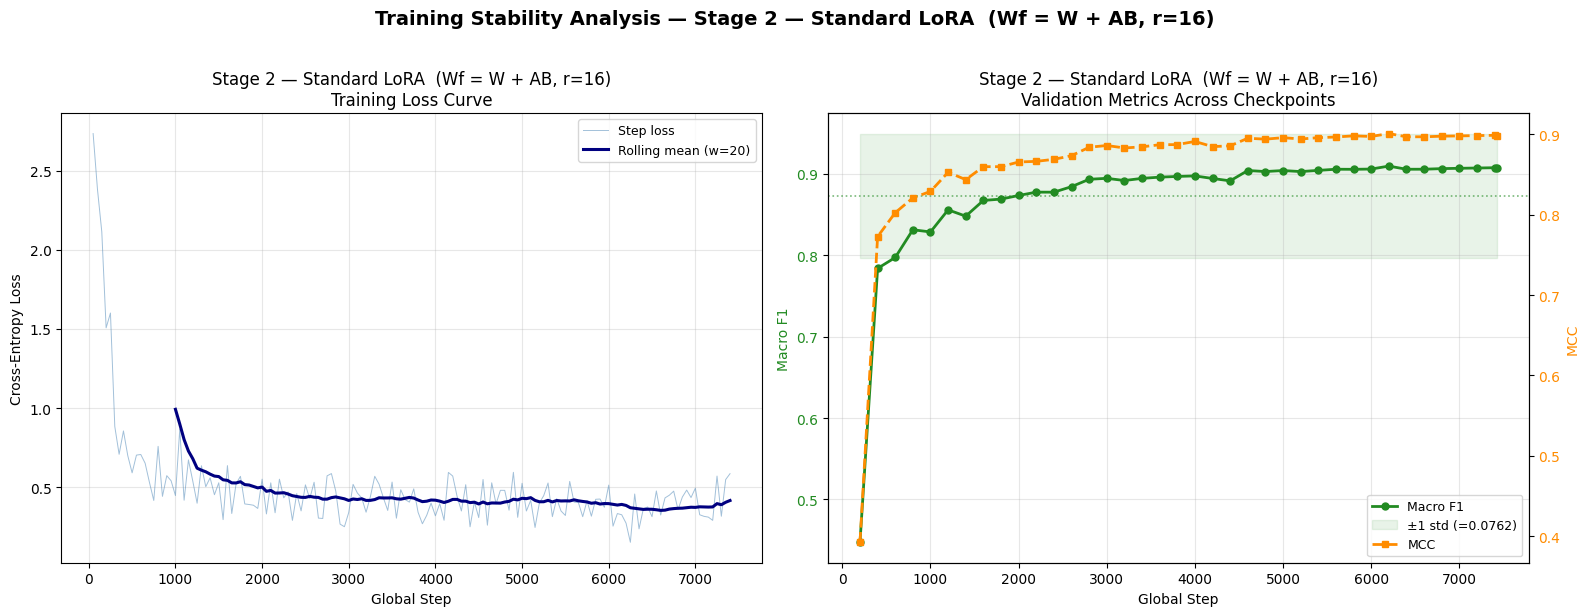

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9087
  Macro F1          : 0.8977  ← PRIMARY METRIC
  Weighted F1       : 0.9089
  Balanced Accuracy : 0.8980
  MCC               : 0.8901  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7535    0.7514    0.7525      1424
             gender     0.9134    0.8971    0.9052      1788
           religion     0.9597    0.9670    0.9634      1971
          ethnicity     0.9786    0.9857    0.9821      1812
                age     0.9833    0.9667    0.9749      1950
other_cyberbullying     0.7966    0.8202    0.8083      1385

           accuracy                         0.9087     10330
          macro avg     0.8975    0.8980    0.8977   

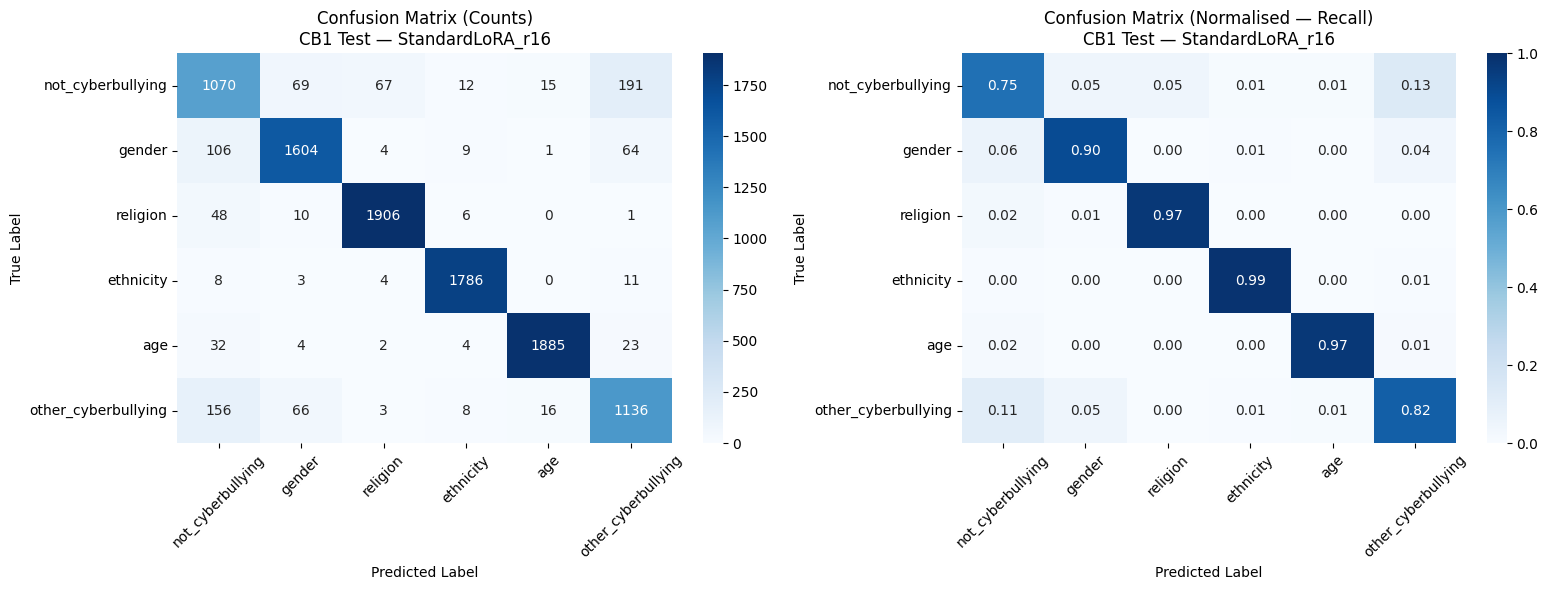


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r16/results_StandardLoRA_r16.csv

════════════════════════════════════════════════════════════
  STAGE 2 RESULTS — Standard LoRA (r=16)
  Formula: Wf = W + AB
  Model  : google/gemma-2-9b-it
════════════════════════════════════════════════════════════
  Macro F1          : 0.8977   ← PRIMARY METRIC
  MCC               : 0.8901
  Accuracy          : 0.9087
  Balanced Accuracy : 0.8980
  Trainable params  : 17,912,832
  Eff. rank Wf      : 2815.98   ← record for Stage 3
  Eff. rank ΔW      : 16.00   (reference)
  Stability score   : 0.371525
════════════════════════════════════════════════════════════

  Stage 1 target      : Phi-4 FS F1 = 0.5757  |  MCC = 0.5614
  Llama-3B  Stage 2   : F1 = 0.8938  |  MCC = 0.8851
  Mistral-7B Stage 2  : F1 = 0.8808  |  MCC = 0.8728
  → Pass results_r16["stability_cb"] to plot_cross_stage_stability() after Stages 3 & 4


In [12]:
results_r16 = run_standard_lora(
    train_df  = train_df,
    val_df    = val_df,
    test_df   = test_df,
    lora_rank = 16,
    run_label = 'StandardLoRA_r16'
)

print('\n' + '═'*60)
print('  STAGE 2 RESULTS — Standard LoRA (r=16)')
print('  Formula: Wf = W + AB')
print('  Model  : google/gemma-2-9b-it')
print('═'*60)
print(f'  Macro F1          : {results_r16["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC               : {results_r16["mcc"]:.4f}')
print(f'  Accuracy          : {results_r16["accuracy"]:.4f}')
print(f'  Balanced Accuracy : {results_r16["balanced_accuracy"]:.4f}')
print(f'  Trainable params  : {results_r16["trainable_params"]:,}')
print(f'  Eff. rank Wf      : {results_r16["avg_eff_rank_Wf"]:.2f}   ← record for Stage 3')
print(f'  Eff. rank ΔW      : {results_r16["avg_eff_rank_dW"]:.2f}   (reference)')
print(f'  Stability score   : {results_r16["stability_score"]}')
print('═'*60)
print()
print('  Stage 1 target      : Phi-4 FS F1 = 0.5757  |  MCC = 0.5614')
print('  Llama-3B  Stage 2   : F1 = 0.8938  |  MCC = 0.8851')
print('  Mistral-7B Stage 2  : F1 = 0.8808  |  MCC = 0.8728')
print('  → Pass results_r16["stability_cb"] to plot_cross_stage_stability() after Stages 3 & 4')

---
## Step 13: Rank Sweep Ablation — r ∈ {4, 8, 16, 32}

**Cross-model pattern to watch**: Llama showed monotonically increasing F1 with rank;
Mistral showed the opposite (decreasing). Gemma-2-9B will reveal whether the inverse
pattern is a 7B-specific quirk or a general property of larger/more-aligned models.

**Runtime**: ~8–10 hours total for 4 runs on A100. Batch size = 4 means more steps
per epoch (~7,426) than Mistral (~3,713). Each run takes approximately 2–2.5 hours.
Consider running ranks individually if session stability is a concern.


───────────────────────────────────────────────────────
  Rank sweep: r = 4
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r4
  Model   : google/gemma-2-9b-it
  Rank r  : 4  |  Alpha: 4  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 256,000
   Pad token : "<pad>" (id=0)
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

...

   Trainable: 4,494,336 / 9,246,221,824  (0.049%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.850637,1.896670,0.350197,0.318536,0.216829
400,0.944444,0.816668,0.728264,0.697189,0.685556
600,0.661985,0.707906,0.813693,0.778948,0.782328
800,0.757016,0.572686,0.832778,0.808602,0.801297
1000,0.424046,0.655961,0.852166,0.830298,0.825960
1200,0.551731,0.470589,0.863072,0.846502,0.838087
1400,0.501693,0.503540,0.874583,0.861335,0.849510
1600,0.694539,0.509005,0.877310,0.857730,0.854471
1800,0.454786,0.520431,0.880945,0.864603,0.856889
2000,0.544566,0.538291,0.880036,0.865699,0.857962


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2815.98
   avg_effective_rank(ΔW) = 4.00  (reference, ≤ r=4)
   LoRA layers measured   = 168

[6] Generating stability report...
   Loss CV (overall)   : 0.7095709925553384
   Loss std (overall)  : 0.3710248134116757
   Val F1 std          : 0.09799707458814835
   Val MCC std         : 0.11157751153391984
   Composite score     : 0.403784
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r4/stability_curves.png


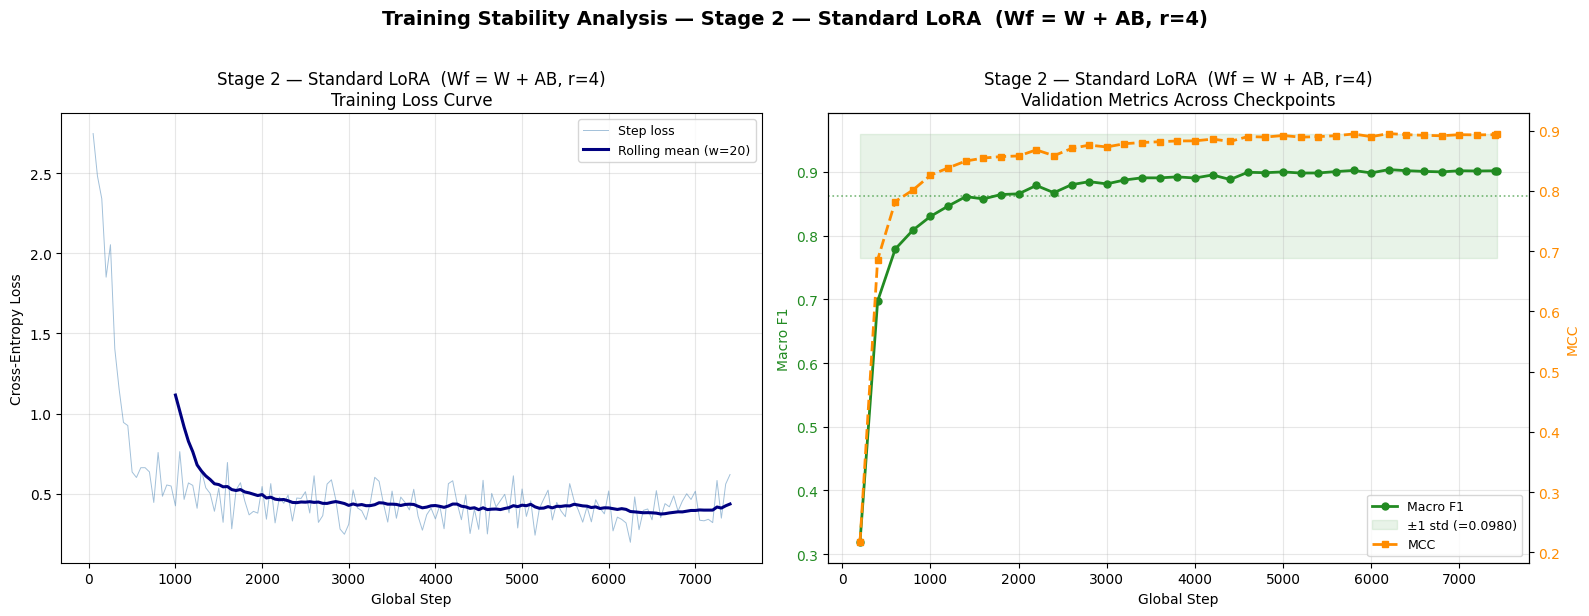

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r4
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9062
  Macro F1          : 0.8951  ← PRIMARY METRIC
  Weighted F1       : 0.9065
  Balanced Accuracy : 0.8953
  MCC               : 0.8871  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7443    0.7500    0.7471      1424
             gender     0.9123    0.9016    0.9069      1788
           religion     0.9567    0.9645    0.9606      1971
          ethnicity     0.9802    0.9812    0.9807      1812
                age     0.9848    0.9636    0.9741      1950
other_cyberbullying     0.7914    0.8108    0.8010      1385

           accuracy                         0.9062     10330
          macro avg     0.8949    0.8953    0.8951    

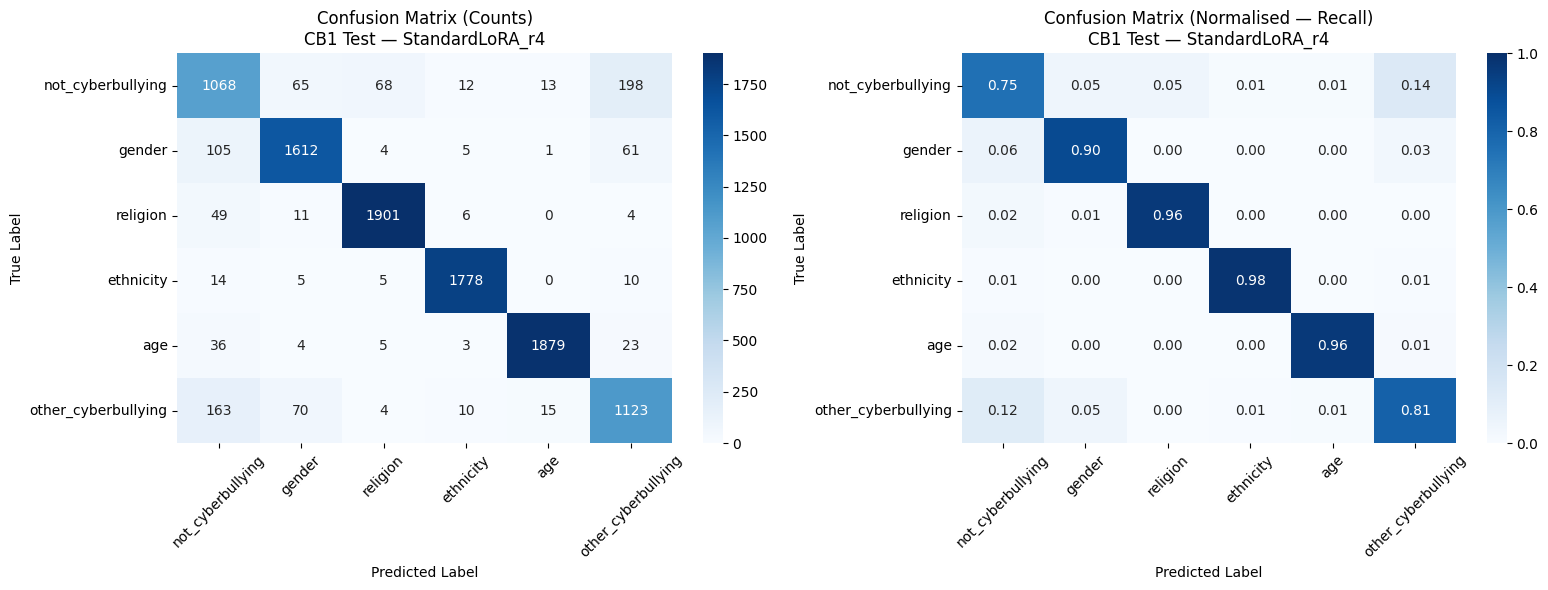


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r4/results_StandardLoRA_r4.csv

───────────────────────────────────────────────────────
  Rank sweep: r = 8
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r8
  Model   : google/gemma-2-9b-it
  Rank r  : 8  |  Alpha: 8  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 256,000
   Pad token : "<pad>" (id=0)
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

...

   Trainable: 8,967,168 / 9,250,694,656  (0.097%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.711656,1.729089,0.415632,0.373383,0.297060
400,0.823872,0.739356,0.771281,0.751871,0.734670
600,0.688269,0.684784,0.826113,0.795267,0.797601
800,0.754977,0.568170,0.832475,0.806691,0.802541
1000,0.458947,0.726881,0.851560,0.827752,0.826241
1200,0.519685,0.498691,0.867616,0.849325,0.844457
1400,0.529108,0.520560,0.867313,0.851250,0.842442
1600,0.661617,0.464247,0.886701,0.870847,0.864994
1800,0.407958,0.495257,0.883066,0.868560,0.859333
2000,0.610428,0.532225,0.878522,0.864584,0.856458


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2815.98
   avg_effective_rank(ΔW) = 8.00  (reference, ≤ r=8)
   LoRA layers measured   = 168

[6] Generating stability report...
   Loss CV (overall)   : 0.6906204262544922
   Loss std (overall)  : 0.351514848482927
   Val F1 std          : 0.08866073261724457
   Val MCC std         : 0.09870150954494758
   Composite score     : 0.389641
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r8/stability_curves.png


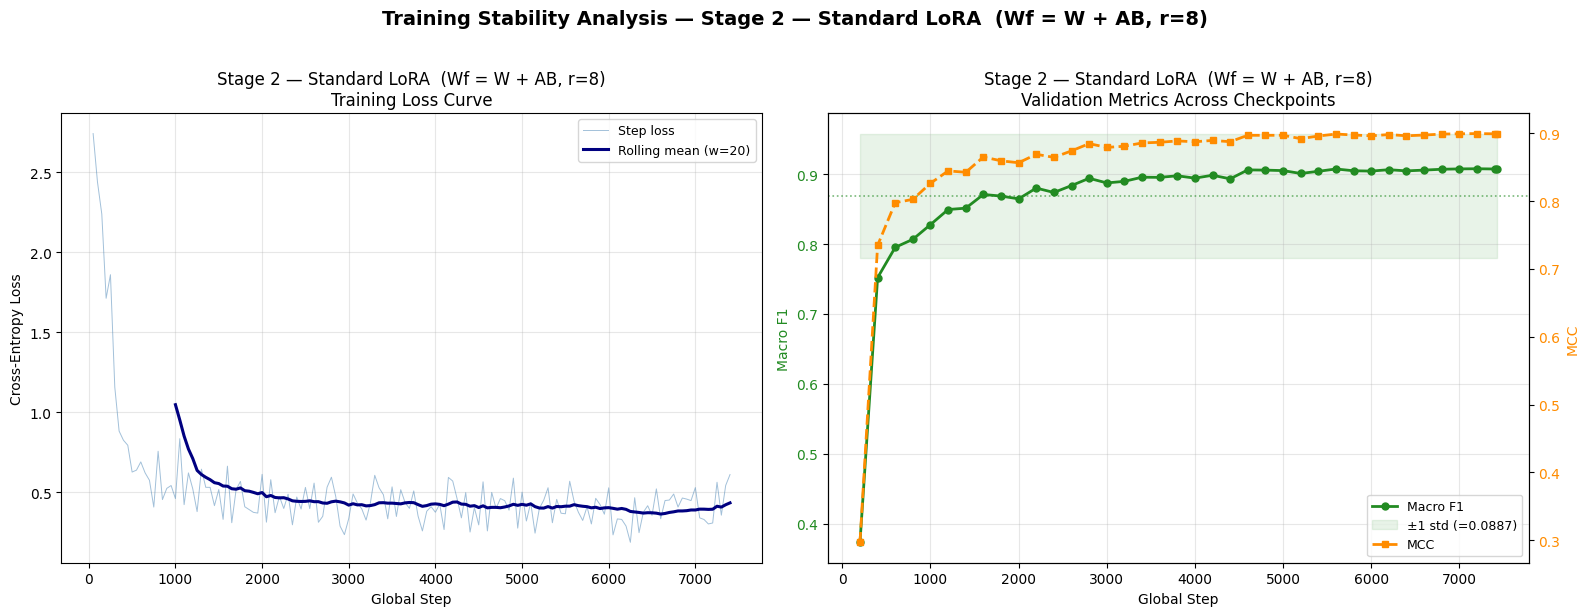

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r8
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9064
  Macro F1          : 0.8954  ← PRIMARY METRIC
  Weighted F1       : 0.9067
  Balanced Accuracy : 0.8957
  MCC               : 0.8873  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7463    0.7521    0.7492      1424
             gender     0.9131    0.8937    0.9033      1788
           religion     0.9577    0.9640    0.9608      1971
          ethnicity     0.9775    0.9829    0.9802      1812
                age     0.9828    0.9651    0.9739      1950
other_cyberbullying     0.7942    0.8166    0.8053      1385

           accuracy                         0.9064     10330
          macro avg     0.8953    0.8957    0.8954    

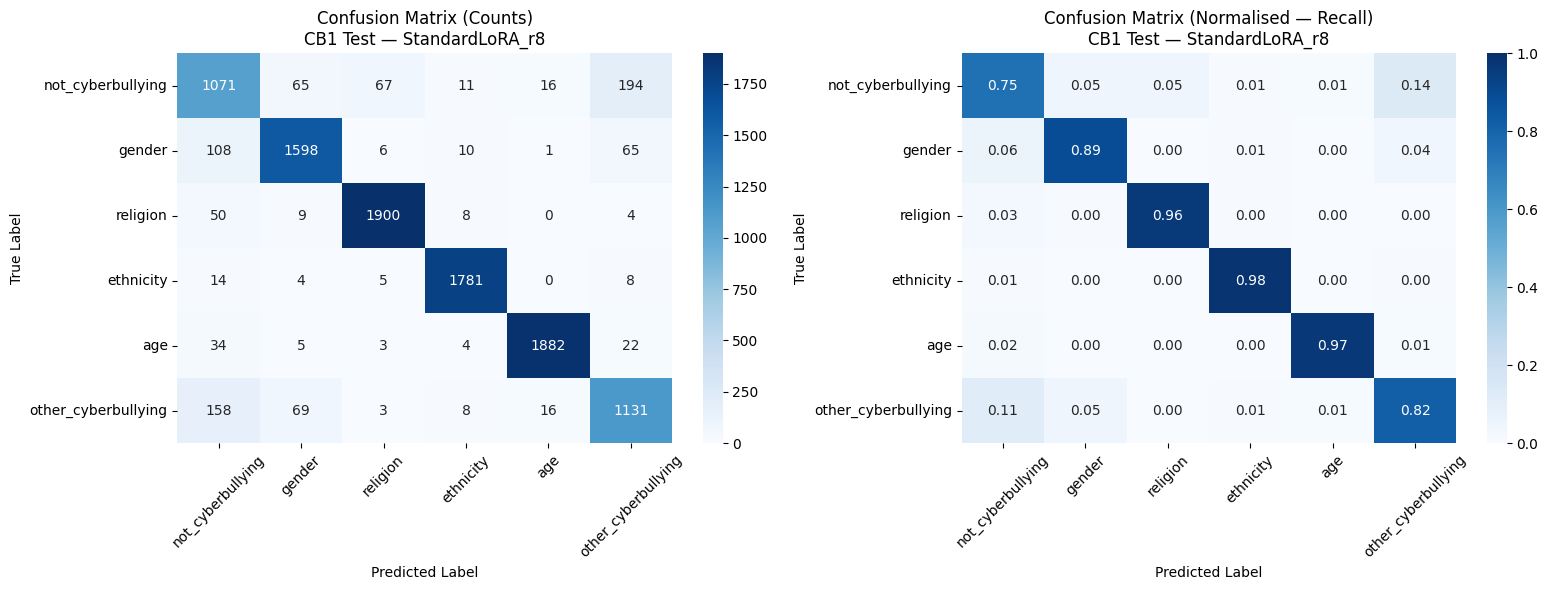


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r8/results_StandardLoRA_r8.csv

───────────────────────────────────────────────────────
  Rank sweep: r = 16
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r16
  Model   : google/gemma-2-9b-it
  Rank r  : 16  |  Alpha: 16  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 256,000
   Pad token : "<pad>" (id=0)
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

...

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.505211,1.503776,0.494093,0.447898,0.392986
400,0.854774,0.634919,0.806422,0.782658,0.771970
600,0.715305,0.646613,0.828234,0.795837,0.801605


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt

Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.505211,1.503776,0.494093,0.447898,0.392986
400,0.854774,0.634919,0.806422,0.782658,0.771970
600,0.715305,0.646613,0.828234,0.795837,0.801605
800,0.758429,0.509939,0.849137,0.830901,0.820463
1000,0.455028,0.795714,0.853984,0.829792,0.829549
1200,0.538343,0.506430,0.871554,0.851313,0.849807
1400,0.566877,0.535558,0.868222,0.849031,0.844744
1600,0.629650,0.459504,0.882157,0.867066,0.859313
1800,0.389251,0.508771,0.882460,0.867437,0.858718
2000,0.541845,0.510353,0.887610,0.874053,0.866457


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2815.98
   avg_effective_rank(ΔW) = 16.00  (reference, ≤ r=16)
   LoRA layers measured   = 168

[6] Generating stability report...
   Loss CV (overall)   : 0.6661944754728717
   Loss std (overall)  : 0.33167699171926673
   Val F1 std          : 0.07648947298917343
   Val MCC std         : 0.08297136345310364
   Composite score     : 0.371342
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r16/stability_curves.png


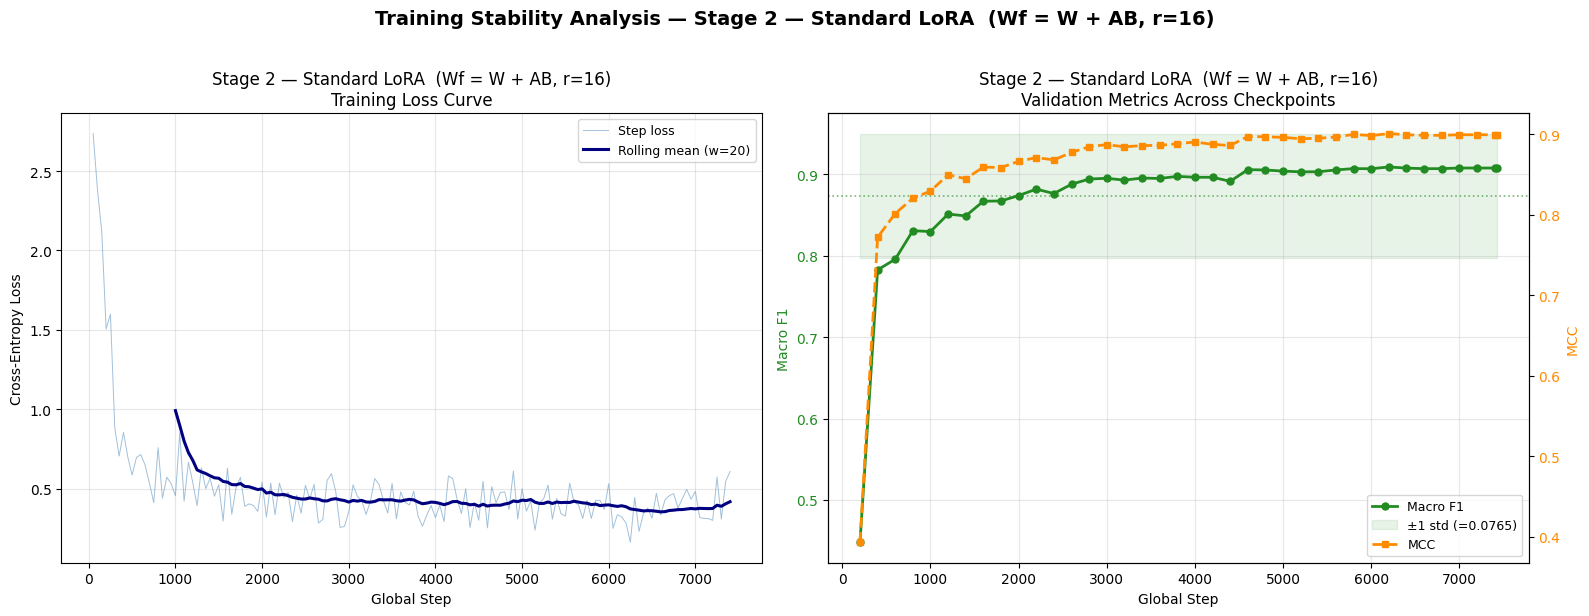

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r16
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9095
  Macro F1          : 0.8986  ← PRIMARY METRIC
  Weighted F1       : 0.9097
  Balanced Accuracy : 0.8989
  MCC               : 0.8910  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7524    0.7556    0.7540      1424
             gender     0.9144    0.8965    0.9054      1788
           religion     0.9607    0.9675    0.9641      1971
          ethnicity     0.9786    0.9857    0.9821      1812
                age     0.9854    0.9667    0.9759      1950
other_cyberbullying     0.7992    0.8217    0.8103      1385

           accuracy                         0.9095     10330
          macro avg     0.8985    0.8989    0.8986   

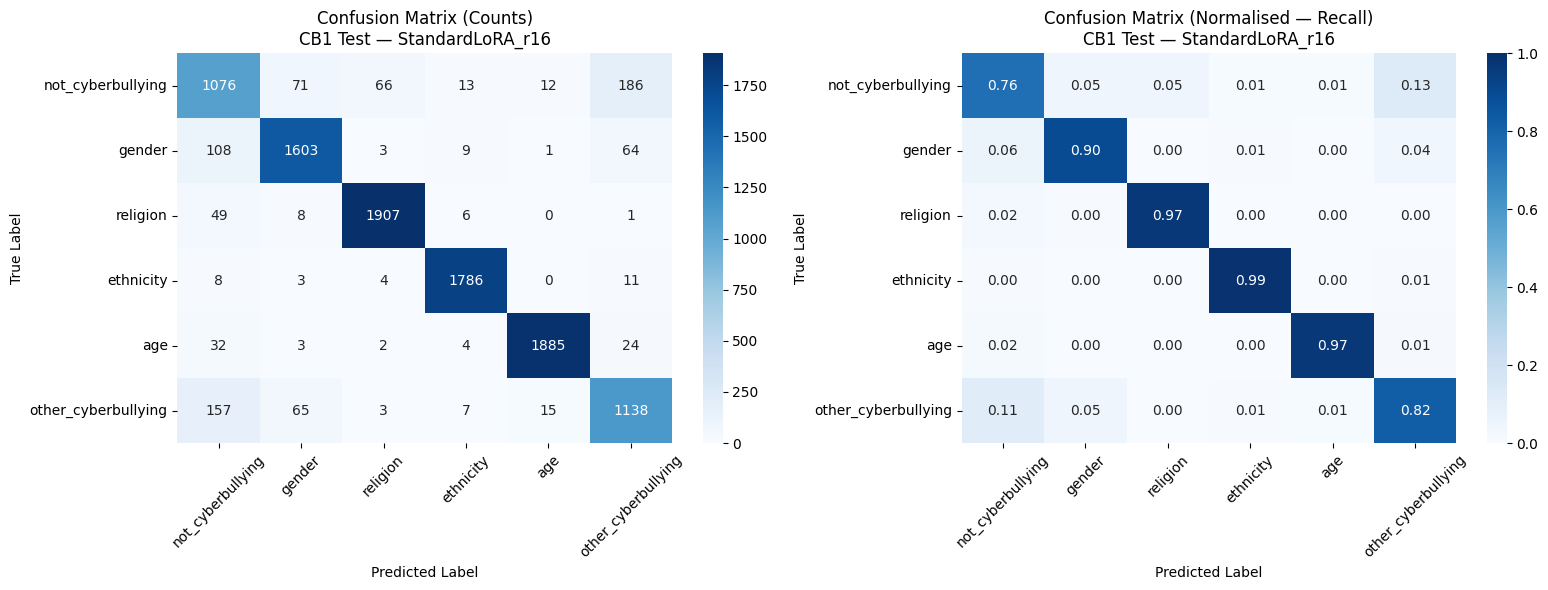


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r16/results_StandardLoRA_r16.csv

───────────────────────────────────────────────────────
  Rank sweep: r = 32
───────────────────────────────────────────────────────
✓ All random seeds fixed to 42.

  STAGE 2 — STANDARD LoRA  |  StandardLoRA_r32
  Model   : google/gemma-2-9b-it
  Rank r  : 32  |  Alpha: 32  |  Scaling: 1.0
  Formula : Wf = W + AB
  Epochs  : 1  (single-epoch protocol)

[1] Loading tokenizer...
   Vocab size: 256,000
   Pad token : "<pad>" (id=0)
[2] Mapping labels and preparing datasets...


Map:   0%|          | 0/29703 [00:00<?, ? examples/s]

Map:   0%|          | 0/3301 [00:00<?, ? examples/s]

   Train: 29,703 | Val: 3,301 | Test: 10,330
[3] Loading model (4-bit NF4 QLoRA)...


Loading weights:   0%|          | 0/464 [00:00<?, ?it/s]

...

   Trainable: 35,804,160 / 9,277,531,648  (0.386%)
[4] Training — 1 epoch (single-epoch protocol)...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss,Accuracy,F1,Mcc
200,1.257543,1.303701,0.568919,0.522708,0.485519
400,0.876819,0.696268,0.806119,0.784565,0.775943
600,0.686564,0.640944,0.831263,0.802773,0.804343
800,0.764616,0.547496,0.838534,0.814848,0.811231
1000,0.439602,0.740357,0.857922,0.836112,0.833526
1200,0.607462,0.528068,0.867919,0.849488,0.845220
1400,0.602697,0.568599,0.860648,0.839999,0.837109
1600,0.664452,0.494147,0.885186,0.867905,0.862857
1800,0.378327,0.566292,0.880339,0.865331,0.856338
2000,0.552632,0.492427,0.887610,0.875085,0.866667


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1263: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/pyt


[5] Computing effective rank of Wf = W + AB...
   avg_effective_rank(Wf) = 2815.98
   avg_effective_rank(ΔW) = 32.00  (reference, ≤ r=32)
   LoRA layers measured   = 168

[6] Generating stability report...
   Loss CV (overall)   : 0.6522850159850163
   Loss std (overall)  : 0.3164565267259708
   Val F1 std          : 0.06691736908525751
   Val MCC std         : 0.07061380296230917
   Composite score     : 0.359601
   Interpretation      : 🔴  Unstable — investigate
  ✓ Stability plot saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r32/stability_curves.png


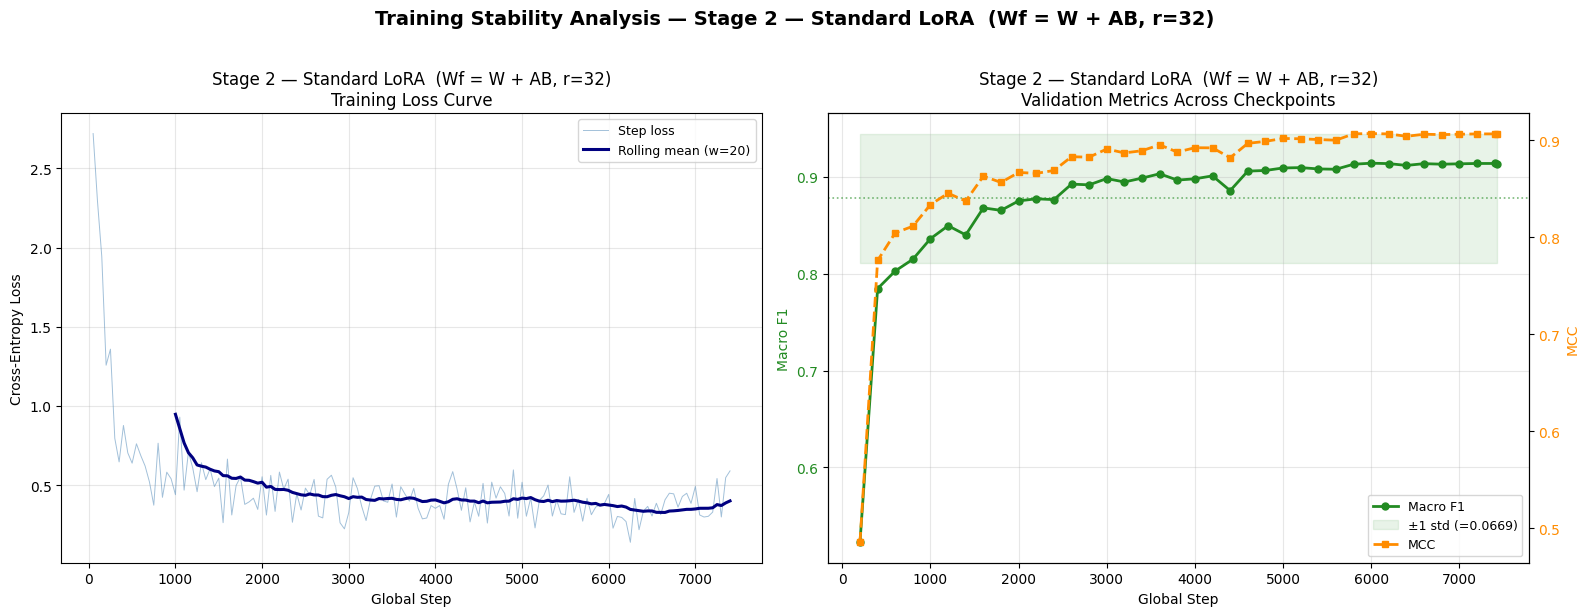

[7] Running inference on held-out test set (25% of full dataset)...

═════════════════════════════════════════════════════════════════
FINAL EVALUATION — CB1 Test — StandardLoRA_r32
═════════════════════════════════════════════════════════════════
  Accuracy          : 0.9116
  Macro F1          : 0.9010  ← PRIMARY METRIC
  Weighted F1       : 0.9119
  Balanced Accuracy : 0.9014
  MCC               : 0.8936  ← SECONDARY METRIC

  Classification Report:
                     precision    recall  f1-score   support

  not_cyberbullying     0.7552    0.7584    0.7568      1424
             gender     0.9147    0.8999    0.9072      1788
           religion     0.9645    0.9655    0.9650      1971
          ethnicity     0.9803    0.9884    0.9843      1812
                age     0.9859    0.9672    0.9764      1950
other_cyberbullying     0.8039    0.8289    0.8162      1385

           accuracy                         0.9116     10330
          macro avg     0.9008    0.9014    0.9010   

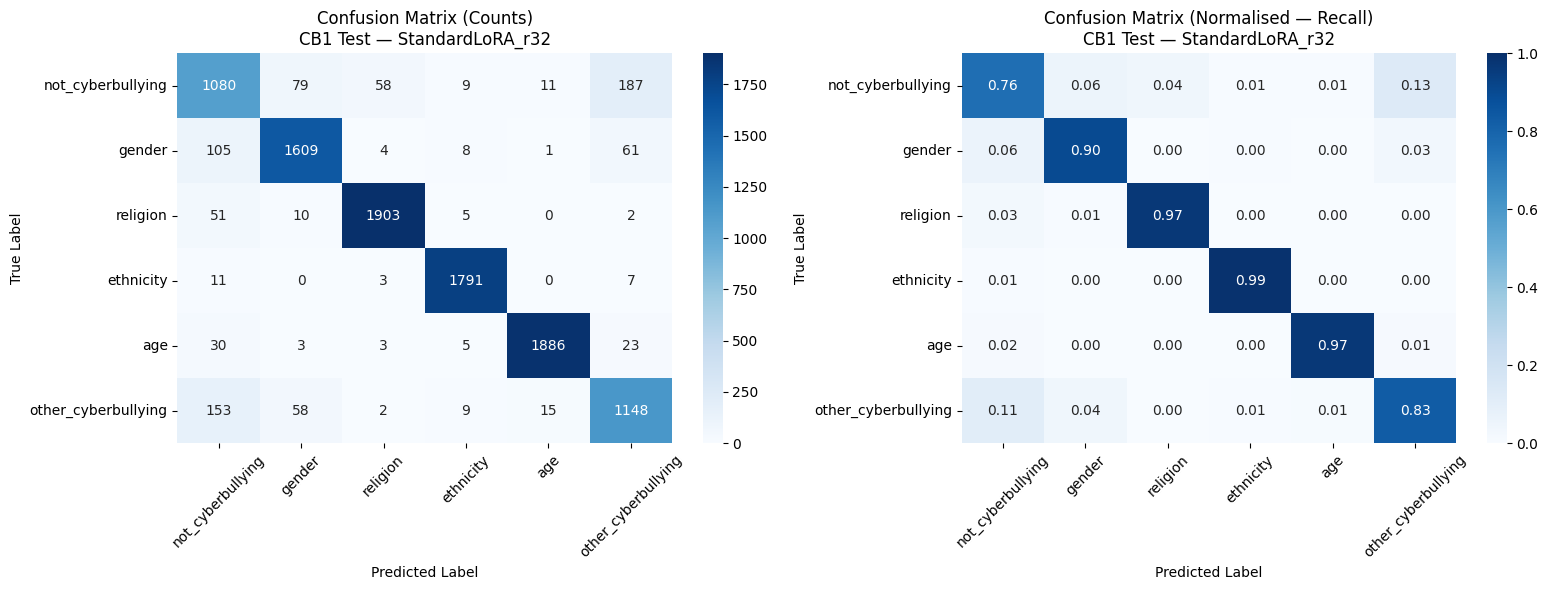


✓ Results saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/StandardLoRA_r32/results_StandardLoRA_r32.csv

═════════════════════════════════════════════════════════════════════════════════════
RANK SWEEP RESULTS — Stage 2 Standard LoRA
Model: google/gemma-2-9b-it
═════════════════════════════════════════════════════════════════════════════════════
 Rank (r)  Trainable Params  Macro F1    MCC  Accuracy  Eff. Rank (Wf)  Eff. Rank (ΔW)  Stability Score
        4           4494336    0.8951 0.8871    0.9062         2815.98             4.0         0.403784
        8           8967168    0.8954 0.8873    0.9064         2815.98             8.0         0.389641
       16          17912832    0.8986 0.8910    0.9095         2815.98            16.0         0.371342
       32          35804160    0.9010 0.8936    0.9116         2815.98            32.0         0.359601

✓ Summary saved → /content/drive/MyDrive/Results/CB1_StandardLoRA_Gemma2_9B/rank_sweep_summary.csv


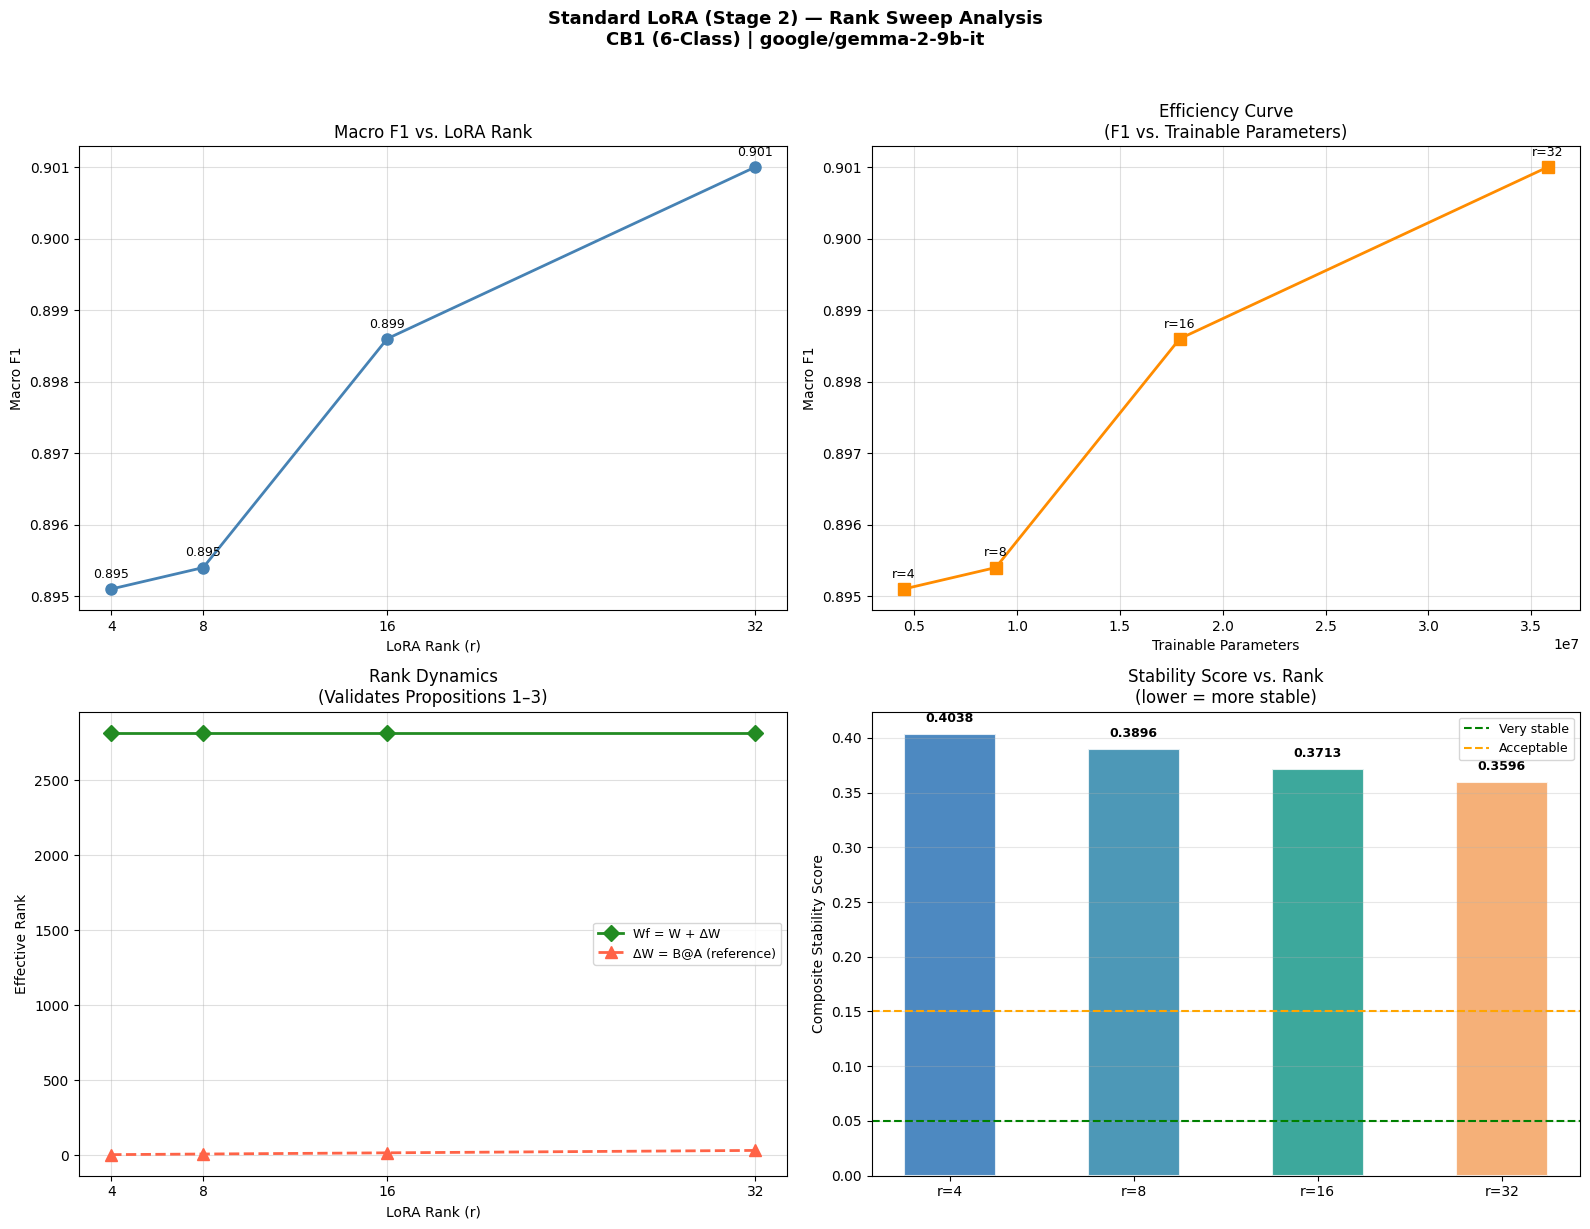

✓ Rank sweep plots saved.


In [13]:
# ════════════════════════════════════════════════════════════════════════════
# RANK SWEEP: r ∈ {4, 8, 16, 32}
# Runtime warning: ~8-10 hours total on A100 (batch=4, ~7,426 steps/run)
# Each rank saves its CSV to Drive immediately on completion.
# If session disconnects, re-run only missing ranks.
# ════════════════════════════════════════════════════════════════════════════

all_rank_results = []

for r in RANK_SWEEP:
    print(f'\n{"─"*55}')
    print(f'  Rank sweep: r = {r}')
    print(f'{"─"*55}')
    res = run_standard_lora(
        train_df  = train_df,
        val_df    = val_df,
        test_df   = test_df,
        lora_rank = r,
        run_label = f'StandardLoRA_r{r}'
    )
    all_rank_results.append(res)

summary_df = pd.DataFrame([{
    'Rank (r)':         res['lora_rank'],
    'Trainable Params': res['trainable_params'],
    'Macro F1':         round(res['macro_f1'],         4),
    'MCC':              round(res['mcc'],               4),
    'Accuracy':         round(res['accuracy'],          4),
    'Eff. Rank (Wf)':   round(res['avg_eff_rank_Wf'],  2),
    'Eff. Rank (ΔW)':   round(res['avg_eff_rank_dW'],  2),
    'Stability Score':  round(res['stability_score'],  6),
} for res in all_rank_results])

print('\n' + '═'*85)
print('RANK SWEEP RESULTS — Stage 2 Standard LoRA')
print('Model: google/gemma-2-9b-it')
print('═'*85)
print(summary_df.to_string(index=False))

summary_path = os.path.join(OUTPUT_DIR, 'rank_sweep_summary.csv')
summary_df.to_csv(summary_path, index=False)
print(f'\n✓ Summary saved → {summary_path}')

# ── 4-panel figure ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0,0].plot(summary_df['Rank (r)'], summary_df['Macro F1'],
               'o-', color='steelblue', linewidth=2, markersize=8)
for _, row in summary_df.iterrows():
    axes[0,0].annotate(f'{row["Macro F1"]:.3f}', (row['Rank (r)'], row['Macro F1']),
                       textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
axes[0,0].set_title('Macro F1 vs. LoRA Rank', fontsize=12)
axes[0,0].set_xlabel('LoRA Rank (r)'); axes[0,0].set_ylabel('Macro F1')
axes[0,0].set_xticks(RANK_SWEEP); axes[0,0].grid(True, alpha=0.4)

axes[0,1].plot(summary_df['Trainable Params'], summary_df['Macro F1'],
               's-', color='darkorange', linewidth=2, markersize=8)
for _, row in summary_df.iterrows():
    axes[0,1].annotate(f'r={int(row["Rank (r)"])}', (row['Trainable Params'], row['Macro F1']),
                       textcoords='offset points', xytext=(0,8), ha='center', fontsize=9)
axes[0,1].set_title('Efficiency Curve\n(F1 vs. Trainable Parameters)', fontsize=12)
axes[0,1].set_xlabel('Trainable Parameters'); axes[0,1].set_ylabel('Macro F1')
axes[0,1].grid(True, alpha=0.4)

axes[1,0].plot(summary_df['Rank (r)'], summary_df['Eff. Rank (Wf)'],
               'D-', color='forestgreen', linewidth=2, markersize=8, label='Wf = W + ΔW')
axes[1,0].plot(summary_df['Rank (r)'], summary_df['Eff. Rank (ΔW)'],
               '^--', color='tomato', linewidth=2, markersize=8, label='ΔW = B@A (reference)')
axes[1,0].set_title('Rank Dynamics\n(Validates Propositions 1–3)', fontsize=12)
axes[1,0].set_xlabel('LoRA Rank (r)'); axes[1,0].set_ylabel('Effective Rank')
axes[1,0].set_xticks(RANK_SWEEP); axes[1,0].legend(fontsize=9); axes[1,0].grid(True, alpha=0.4)

axes[1,1].bar(range(len(RANK_SWEEP)), summary_df['Stability Score'],
              color=['#2E75B6','#2E86AB','#1B998B','#F4A261'],
              alpha=0.85, edgecolor='white', linewidth=1.5, width=0.5)
for i, (_, row) in enumerate(summary_df.iterrows()):
    axes[1,1].text(i, row['Stability Score']+max(summary_df['Stability Score'])*0.02,
                   f'{row["Stability Score"]:.4f}', ha='center', va='bottom',
                   fontsize=9, fontweight='bold')
axes[1,1].axhline(0.05, color='green',  linestyle='--', linewidth=1.5, label='Very stable')
axes[1,1].axhline(0.15, color='orange', linestyle='--', linewidth=1.5, label='Acceptable')
axes[1,1].set_xticks(range(len(RANK_SWEEP)))
axes[1,1].set_xticklabels([f'r={r}' for r in RANK_SWEEP], fontsize=10)
axes[1,1].set_title('Stability Score vs. Rank\n(lower = more stable)', fontsize=12)
axes[1,1].set_ylabel('Composite Stability Score')
axes[1,1].legend(fontsize=9); axes[1,1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Standard LoRA (Stage 2) — Rank Sweep Analysis\nCB1 (6-Class) | google/gemma-2-9b-it',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'rank_sweep_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('✓ Rank sweep plots saved.')

---
## Step 14: Cross-Stage Stability Comparison (Run After All Stages Complete)

In [14]:
# ── Cross-stage comparison — uncomment after Stages 3 & 4 complete ──────────
# plot_cross_stage_stability(
#     stage_reports={
#         'Stage 2\nWf = W + AB':        results_r16['stability_cb'].get_stability_report(),
#         'Stage 3\nWf = W(I+UV)':       results_s3['stability_cb'].get_stability_report(),
#         'Stage 4\nWf = W(I+UV)+AB':    results_s4['stability_cb'].get_stability_report(),
#     },
#     save_path=os.path.join(OUTPUT_DIR, 'cross_stage_stability.png')
# )

print('Stage 2 stability report (r=16):')
rep = results_r16['stability_cb'].get_stability_report()
for k in ['loss_cv_overall','loss_std_overall','val_f1_std','val_mcc_std','stability_score']:
    print(f'  {k:<20} : {rep.get(k, "N/A")}')

print('\n' + '═'*70)
print('  STAGE 2 COMPLETE — STANDARD (ADDITIVE) LoRA')
print('  Formula  : Wf = W + AB')
print('  Model    : google/gemma-2-9b-it')
print('  Dataset  : CB1 — 6-Class Cyberbullying Detection')
print('  Split    : 75/25 stratified (protocol-compliant)')
print('═'*70)
print('\n── PRIMARY RESULTS (r=16) ──')
print(f'  Macro F1           : {results_r16["macro_f1"]:.4f}   ← PRIMARY METRIC')
print(f'  MCC                : {results_r16["mcc"]:.4f}')
print(f'  Accuracy           : {results_r16["accuracy"]:.4f}')
print(f'  Balanced Accuracy  : {results_r16["balanced_accuracy"]:.4f}')
print(f'  Trainable params   : {results_r16["trainable_params"]:,}')
print(f'  Eff. rank (Wf)     : {results_r16["avg_eff_rank_Wf"]:.2f}')
print(f'  Stability score    : {results_r16["stability_score"]}')
print('\n── ALL FIXES APPLIED ──')
print('  [✓] Bug 1: effective_rank measures Wf = W + ΔW')
print('  [✓] Bug 2: 6-class label mapping (gender, ethnicity)')
print(f'  [✓] Bug 3: lora_alpha = lora_rank  →  scaling = 1.0')
print('  [✓] Bug 4: EarlyStoppingCallback removed')
print('  [✓] R4   : 75/25 split (protocol-compliant)')
print('  [✓] R5   : 2-panel stability plot')

Stage 2 stability report (r=16):
  loss_cv_overall      : 0.6668192138864825
  loss_std_overall     : 0.33194855986504856
  val_f1_std           : 0.07623083134970178
  val_mcc_std          : 0.08278548497767403
  stability_score      : 0.371525

══════════════════════════════════════════════════════════════════════
  STAGE 2 COMPLETE — STANDARD (ADDITIVE) LoRA
  Formula  : Wf = W + AB
  Model    : google/gemma-2-9b-it
  Dataset  : CB1 — 6-Class Cyberbullying Detection
  Split    : 75/25 stratified (protocol-compliant)
══════════════════════════════════════════════════════════════════════

── PRIMARY RESULTS (r=16) ──
  Macro F1           : 0.8977   ← PRIMARY METRIC
  MCC                : 0.8901
  Accuracy           : 0.9087
  Balanced Accuracy  : 0.8980
  Trainable params   : 17,912,832
  Eff. rank (Wf)     : 2815.98
  Stability score    : 0.371525

── ALL FIXES APPLIED ──
  [✓] Bug 1: effective_rank measures Wf = W + ΔW
  [✓] Bug 2: 6-class label mapping (gender, ethnicity)
  [✓] Bug